**ECE 447: Data Analysis and Machine Learning for Engineers**

# Assignment 3 - Problem 1
**Classification: Decision Trees, Random Forests, SVMs, and Logistic**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report,confusion_matrix
import warnings
warnings.simplefilter("ignore")

In [30]:
### A3-P1 The file (mushrooms.csv) contains data related to mushrooms.
# The mushrooms belong to two classes (class): e (edible) and p (poisonous).
# The dataset contains a variety of categorical features describing mushroom characteristics.
# The goal is to use these features to predict the target variable class.
# You will train a variety of models.
# You may use t-test (ttest_ind) from scipy.stats or cross-validations to compare models during your analysis.

In [31]:
### A3-P1 a) Load the data and make sure you understand it.

data = pd.read_csv('data/mushrooms.csv')
data.head()

df = data

In [32]:
### A3-P1 b) Compute and visualize the correlation matrix as a heatmap.
# To compute correlations, first convert the categorical features into
# numerical representations using the following:

from sklearn.preprocessing import LabelEncoder

Encoder_Data = LabelEncoder() 
for col in df.columns:
    df[col] = Encoder_Data.fit_transform(df[col])
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,0,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,0,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,0,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,0,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,0,1,0,3,0,1


Label encoding is ideal for **ordinal categorical** data that exhibit a natural sequence or ranking. For instance, educational qualifications such as "High School," "Bachelor's," "Master's," and "Ph.D." can be numerically represented as 0, 1, 2, and 3, respectively. 

Conversely, for **nominal categorical data without an inherent order**, one-hot encoding tends to be the preferred method. This approach transforms each category into a separate binary column, with each instance marked by **1** in its respective column and **0s** in all others.

Using label encoding on nominal data could erroneously suggest to models an order among categories that does not exist, potentially skewing outcomes.
One-hot encoding, however, can greatly expand your dataset's dimensionality, risking the curse of dimensionality with numerous unique categories. In such scenarios, applying feature selection or dimensionality reduction methods becomes necessary.

Hence, for the training data, we will employ one-hot encoding or dummy labels, while label encoding will be reserved for the target/output.

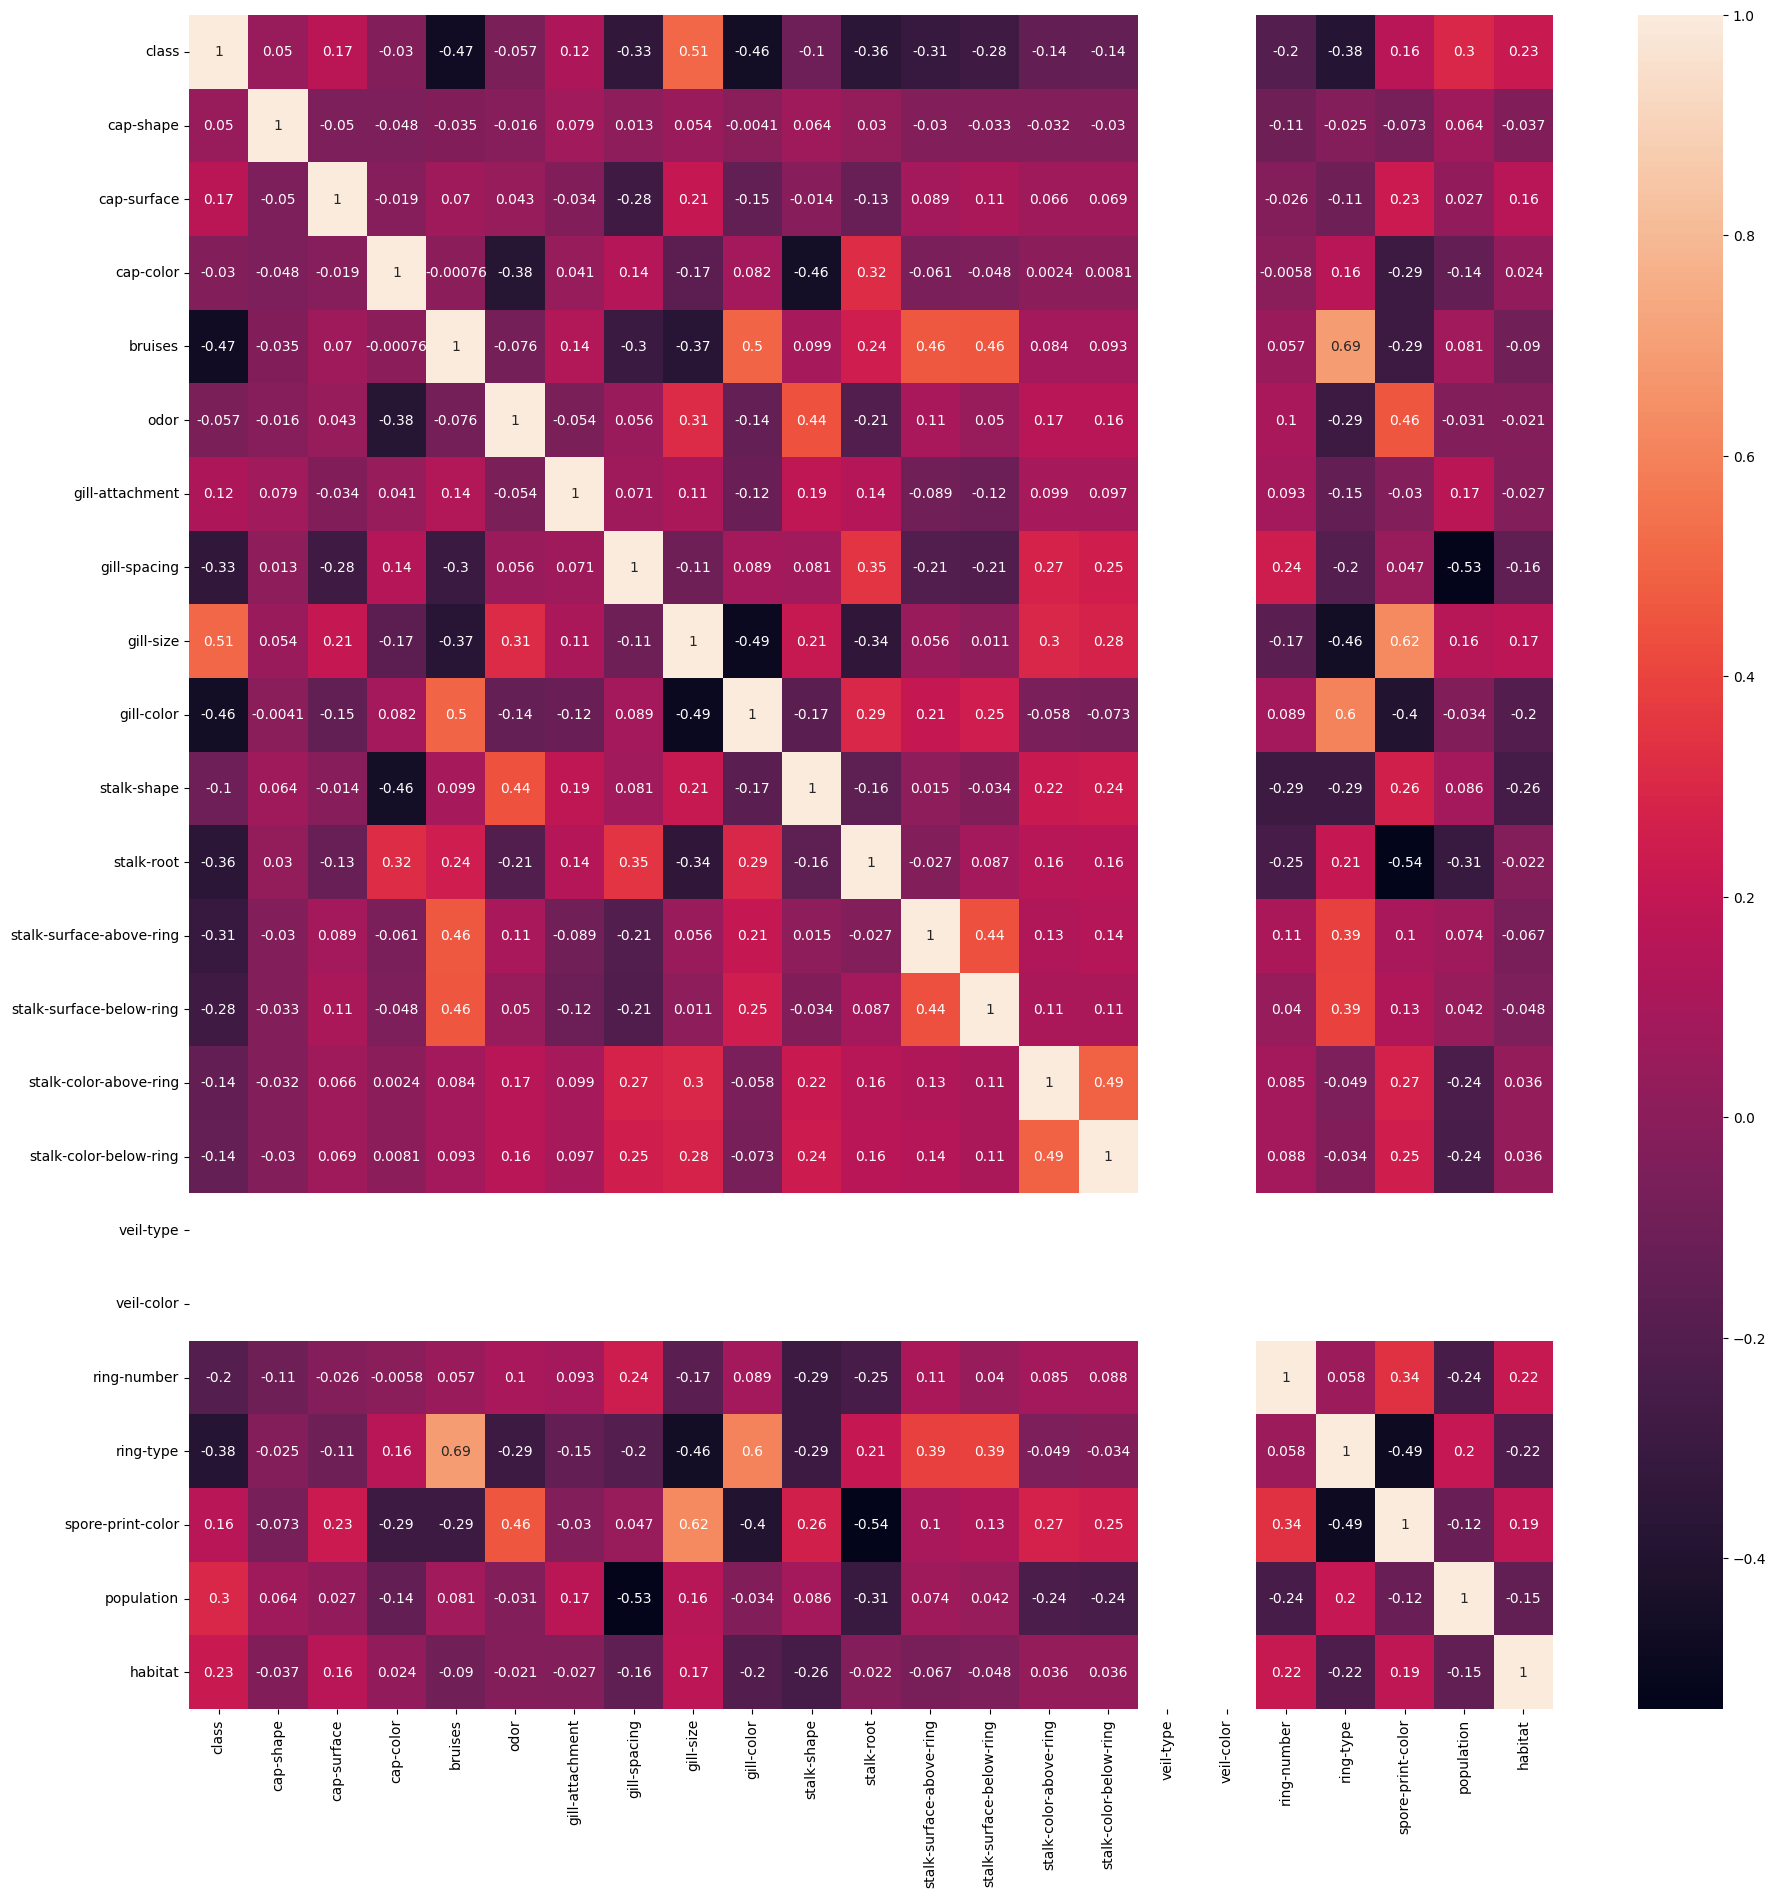

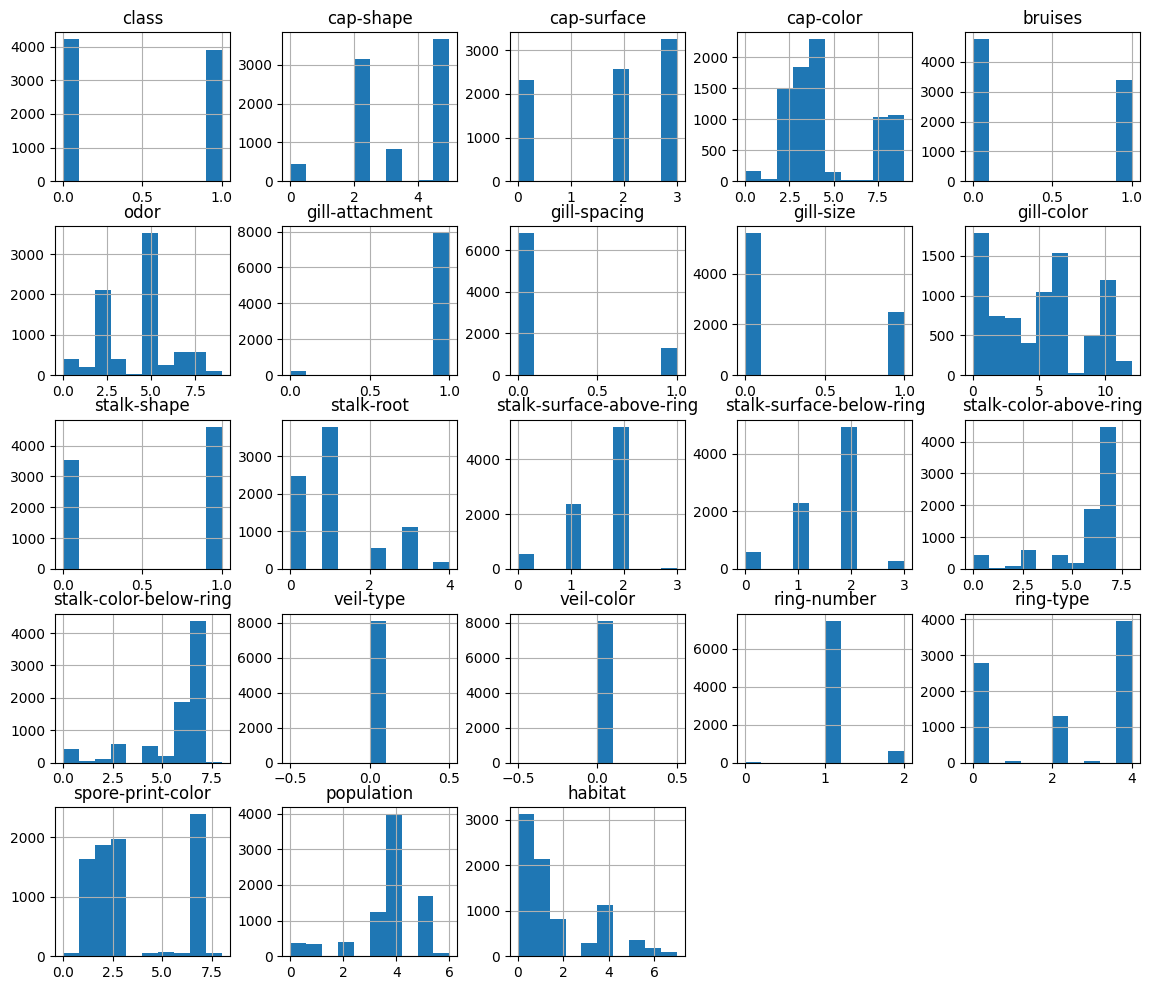

In [33]:
### A3-P1 c) Create histograms for all features and examine them to identify any anomalies.
# Describe any irregularities you observe and explain what, if anything, should be addressed
# or corrected prior to further data analysis.

corr = df.corr()
plt.subplots(figsize=(22,22))
sns.heatmap(corr, annot=True)

hist = df.hist(figsize=[14,12])

In [34]:
#### A3-P1 d) Load the dataset again using the original features.
# Identify and fix any anomalies.
# Determine whether missing values are present and explain how they are handled.
# Discuss whether the missing data appear to be random or if there is an identifiable pattern.
# Explain whether removing the missing data is an appropriate approach, and suggest possible alternatives.
# Finally, identify any outliers and describe how they are handled.

df = pd.read_csv('data/mushrooms.csv')
df.head()

print(df.isna().sum())

# It shows that odor, gill-color, population, habitat has NA.
# veil-color also is completely missing.
# Removing those will result in removing a lot of data. So, we can use imputation.
# This is categorical so we do fill in with word missing
# (in case the missing might have a meaning and usefulness)

cols_with_missing = df.columns[df.isna().any()]
print(cols_with_missing)
for col in cols_with_missing:
    df[col] = df[col].fillna("missing")

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                          92
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                    91
stalk-shape                    0
stalk-root                     0
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                  8124
ring-number                    0
ring-type                      0
spore-print-color              0
population                    91
habitat                       91
dtype: int64
Index(['odor', 'gill-color', 'veil-color', 'population', 'habitat'], dtype='object')


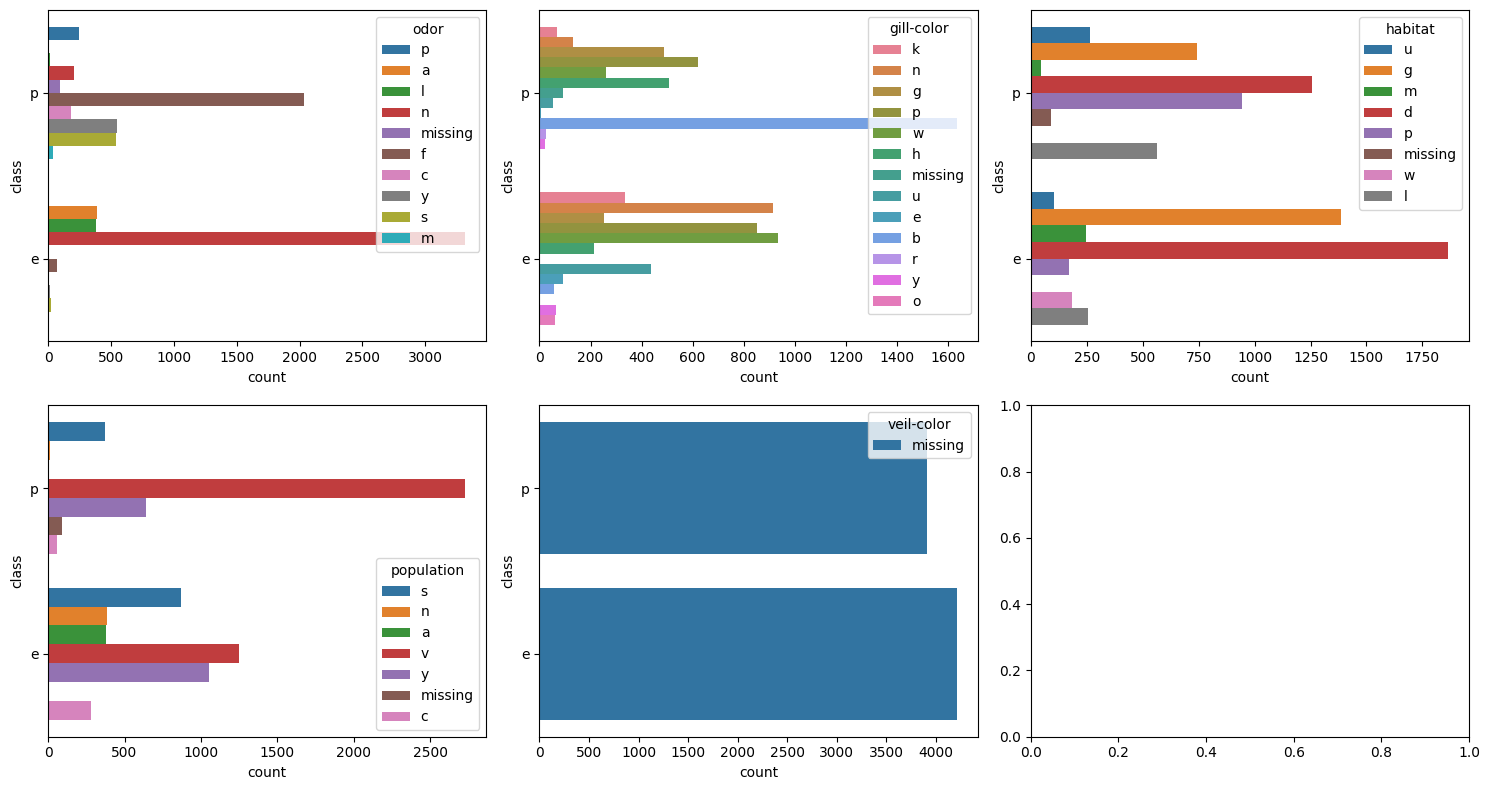

In [35]:
# ans: taking a look here, you can see that first the whole veil-color is missing values.
# second, the missing values are only coming from the p class. there is no missing on the feature with label e.
# so, we don't know why; as data is given to us. But, removing the whole data may not be a good idea,
# and this missing value might be useful as a discrimination
# maybe it's hard to find those feature for class e. This is a useful info in general.

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

sns.countplot(y=df['class'], hue=df['odor'], ax=ax[0, 0])
sns.countplot(y=df['class'], hue=df['gill-color'], ax=ax[0, 1])
sns.countplot(y=df['class'], hue=df['habitat'], ax=ax[0, 2])
sns.countplot(y=df['class'], hue=df['population'], ax=ax[1, 0])
sns.countplot(y=df['class'], hue=df['veil-color'], ax=ax[1, 1])

plt.tight_layout()
plt.show()

In [36]:
# check the shape and info of the data and use describe

print("Data shape:")
print(df.shape)
print("Data info:")
print(df.info())

df.describe().T

Data shape:
(8124, 23)
Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   ob

,count,unique,top,freq
class,8124,2,e,4213
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,10,n,3524
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,13,b,1691


[Text(0, 0, '3911'), Text(0, 0, '4213')]

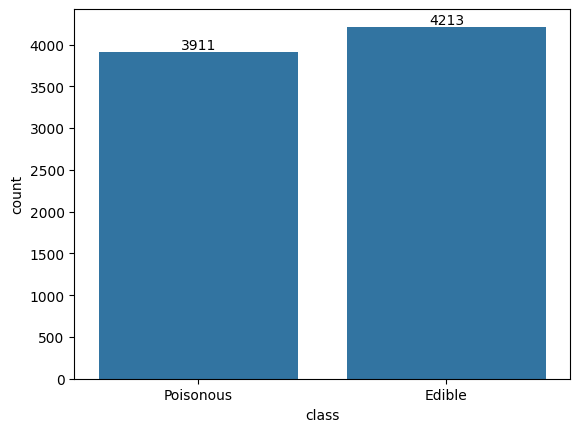

In [37]:
#### A3-P1 e) Use Seaborn to create a count plot showing the number of edible and poisonous mushrooms.
# Discuss whether the dataset is balanced with respect to the class labels.

# for better readability, lets name the name of e to Edible, and p to Poisonous.
# We have more Edible label in the dataset; it is not balanced.

df['class'] = df['class'].apply(lambda x:'Edible' if 'e' in x else 'Poisonous')

ax = sns.countplot(x=df['class'])
ax.bar_label(ax.containers[0])

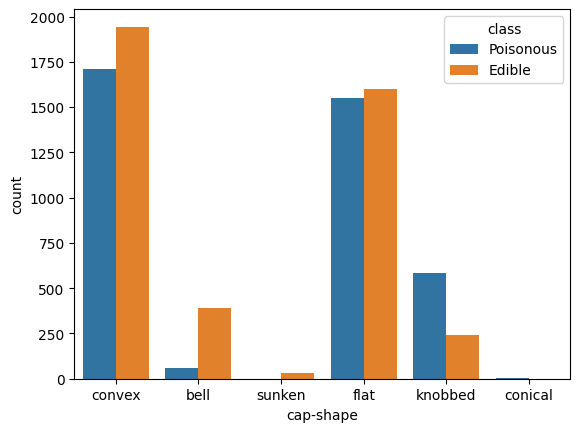

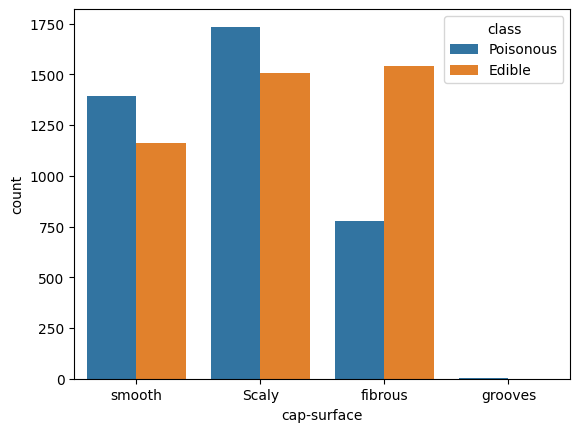

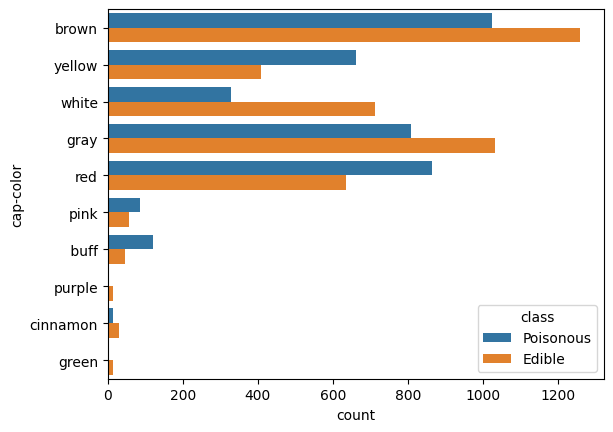

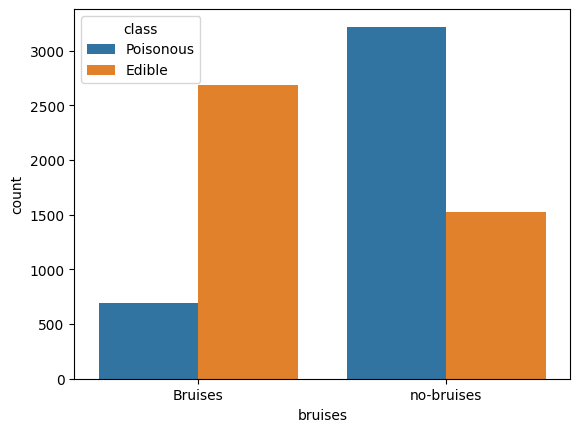

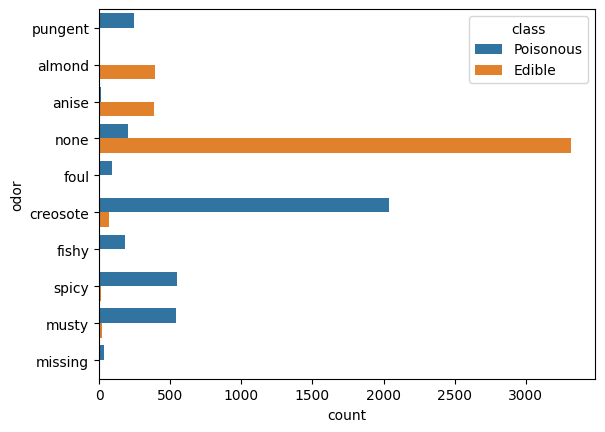

In [38]:
#### A3-P1 f) Use Seaborn to create count plots showing the distribution of
# edible and poisonous mushrooms conditioned on different features in the dataset.
# Comment on the patterns you observe in these plots. Based on your visual analysis,
# discuss which feature(s) appear to play the most important role in classification.
# In particular, state whether the \texttt{odor} feature is useful for classification (yes or no) and explain why.
# Finally, if the \texttt{missing} category is retained as a feature value, discuss
# whether it is likely to play an important role in classification and justify your reasoning.

# here, we are visually looking for feature that have category only active for one class.
# This means that value of the feature if active can be very easily be use to identify the class.
# Odor has a few types that is only active for the blue class.
# particularly, it seems the missing values where coming from only one class;
# so it was not random; as this might be useful information for now, we include in the classification.
# Overall, you get to see useful info, e.g.,
# if there is bruises, the mushroom is more likely to be Edible.

# cap-shape
plt.figure()
ax = sns.countplot(x=df['cap-shape'], hue=df['class'])
ax.set_xticklabels(('convex', 'bell','sunken','flat','knobbed','conical','missing'))

# cap-surface
plt.figure()
ax = sns.countplot(x=df['cap-surface'], hue=df['class'])
ax.set_xticklabels(('smooth', 'Scaly','fibrous','grooves', 'missing'))

# cap-color
plt.figure()
ax = sns.countplot(y=df['cap-color'], hue=df['class'])
ax.set_yticklabels(('brown', 'yellow','white','gray','red','pink',' buff', 'purple', 'cinnamon', 'green', 'missing'))

# bruises
plt.figure()
ax = sns.countplot(x=df['bruises'], hue=df['class'])
ax.set_xticklabels(('Bruises','no-bruises'))

# odor
plt.figure()
ax = sns.countplot(y=df['odor'], hue=df['class'])
ax.set_yticklabels(('pungent','almond', 'anise', 'none', 'foul', 'creosote', 'fishy', 'spicy', 'musty', 'missing'));

In [39]:
#### A3-P1 g) Create the feature matrix $\X$ from the dataset using the input features, and define the target vector $\y$ using the \texttt{class} column.

In [40]:
#### A3-P1 g) Create X and y from the data. X with features, and y as the class columns.

y = df['class']
X = df.drop(labels =['class'],axis=1)


X = X.drop(columns=["odor"])
X = X.drop(columns=["spore-print-color"])
X = X.drop(columns=["gill-size"])

In [41]:
X.head()

,cap-shape,cap-surface,cap-color,bruises,gill-attachment,gill-spacing,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,population,habitat
0,x,s,n,t,f,c,k,e,e,s,s,w,w,p,missing,o,p,s,u
1,x,s,y,t,f,c,k,e,c,s,s,w,w,p,missing,o,p,n,g
2,b,s,w,t,f,c,n,e,c,s,s,w,w,p,missing,o,p,n,m
3,x,y,w,t,f,c,n,e,e,s,s,w,w,p,missing,o,p,s,u
4,x,s,g,f,f,w,k,t,e,s,s,w,w,p,missing,o,e,a,g


In [42]:
#### A3-P1 h) Convert the categorical variables in the feature matrix X into dummy (indicator) variables.
# This technique transforms each multi-category feature into multiple binary variables. Use pd.get_dummies(X} for this step.
# Additionally, apply the LabelEncoder discussed above to transform the target vector y into binary (0/1) labels.

X = pd.get_dummies(X)
X.head()

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_missing,habitat_p,habitat_u,habitat_w
0,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False


In [43]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print(y)

[1 0 0 ... 0 1 0]


In [44]:
#### A3-P1 i) Plan is to train a decision tree classifier using the Gini Index.
# Explain what the Gini Index is and what it measures.
# Discuss how the Gini Index contributes to feature selection in machine learning models.

The Gini Index, also known as Gini Impurity or Gini coefficient, is a measure of impurity or inequality in a dataset. It quantifies the probability of incorrectly classifying a randomly chosen element if it were randomly labeled according to the class distribution in the dataset.

If all samples belong to one class (pure node), then G = 0. If the classes are evenly distributed (maximum impurity for two classes at 50/50), the Gini Index is highest (for binary classification, maximum is 0.5). Thus, the Gini Index measures node impurity.

- It evaluates the impurity of a dataset based on the distribution of class probabilities, with a smaller Gini Index indicating higher dataset purity and better discriminative power of the feature.
- In decision tree algorithms, the Gini Index is used to select the best feature for splitting the data at each node or level of the tree.
- The Gini Index helps rank features by how well they decrease impurity, which is defined as the portion of final nodes' splits that contain both classes of the outcome

In [45]:
#### A3-P1 Decision Tree.

In [46]:
#### A3-P1 j) Use sklearn to train a DecisionTreeClassifier on your data.
# Use train_test_split from sklearn.model_selection to split the dataset.
# Report the model's performance using classification_report and confusion_matrix from sklearn.metrics.


# Split data into training and test datasets
# Used a random_state value of 30 (arbitrarily picked) with an 80:20 split for a consistent split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

In [47]:
#### A3-P1 k) Vary the minimum number of samples in each leaf and
# report the model performance (e.g., accuracy or other appropriate metrics).
# Create a plot with the hyperparameter min_samples_leaf on the x-axis and the performance metric on the y-axis.
# Report and compare performance on both the training and test sets.
# Comment on the results and discuss any observed trends or trade-offs.

# Train the model using the split obtained above
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Measure the model's performance on the test set
y_predict = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict))

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.95       880
           1       0.94      0.93      0.94       745

    accuracy                           0.94      1625
   macro avg       0.94      0.94      0.94      1625
weighted avg       0.94      0.94      0.94      1625

Confusion Matrix:
 [[835  45]
 [ 51 694]]


In [48]:
#### Train decision tree with Gini Index, and measure the performance on the test set

model_gini = DecisionTreeClassifier(criterion="gini")
model_gini.fit(X_train, y_train)

# Measure the model's performance on the test set
y_predict_gini = model_gini.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_gini))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_gini))


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95       880
           1       0.94      0.94      0.94       745

    accuracy                           0.94      1625
   macro avg       0.94      0.94      0.94      1625
weighted avg       0.94      0.94      0.94      1625

Confusion Matrix:
 [[833  47]
 [ 46 699]]


In [49]:
# use min_samples_leaf to 2,20, report performance again

print("DecisionTreeClassifier(criterion=gini, min_samples_leaf=2)")
model_gini_minsample = DecisionTreeClassifier(criterion="gini", min_samples_leaf=2)
model_gini_minsample.fit(X_train, y_train)
y_predict_gini = model_gini_minsample.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_gini))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_gini))

print("DecisionTreeClassifier(criterion=gini, min_samples_leaf=20)")
model_gini_minsample = DecisionTreeClassifier(criterion="gini", min_samples_leaf=20)
model_gini_minsample.fit(X_train, y_train)
y_predict_gini = model_gini_minsample.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_gini))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_gini))

DecisionTreeClassifier(criterion=gini, min_samples_leaf=2)
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95       880
           1       0.96      0.93      0.94       745

    accuracy                           0.95      1625
   macro avg       0.95      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625

Confusion Matrix:
 [[850  30]
 [ 54 691]]
DecisionTreeClassifier(criterion=gini, min_samples_leaf=20)
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       880
           1       0.97      0.96      0.96       745

    accuracy                           0.97      1625
   macro avg       0.97      0.97      0.97      1625
weighted avg       0.97      0.97      0.97      1625

Confusion Matrix:
 [[854  26]
 [ 28 717]]


Text(0.5, 0, 'min samples leaf')

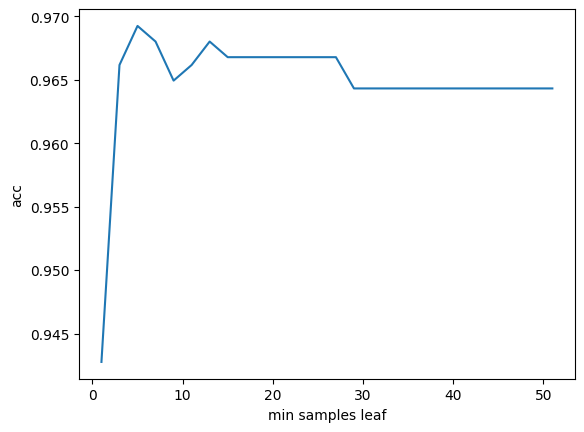

In [50]:
# create a plot acc vs min_samples_leaf

leaf = list(np.linspace(1, 51, 26))
acc = list()
for min_samples_leaf in leaf:
    min_samples_leaf = int(min_samples_leaf)
    model_gini_minsample = DecisionTreeClassifier(criterion="gini", min_samples_leaf=min_samples_leaf)
    model_gini_minsample.fit(X_train, y_train)
    y_predict_gini = model_gini_minsample.predict(X_test)
    acc.append(sum((y_test - y_predict_gini) == 0)/len(y_predict_gini))

plt.plot(leaf, acc)
plt.ylabel("acc")
plt.xlabel("min samples leaf")

# too low min samples leaf will result in overfitting,
# and too high reuslts in low acc due to low resolution of feature space in classification.
# You wanna set the min samples leaf to relatively a low number, but not too low.


Text(0.5, 0, 'depth')

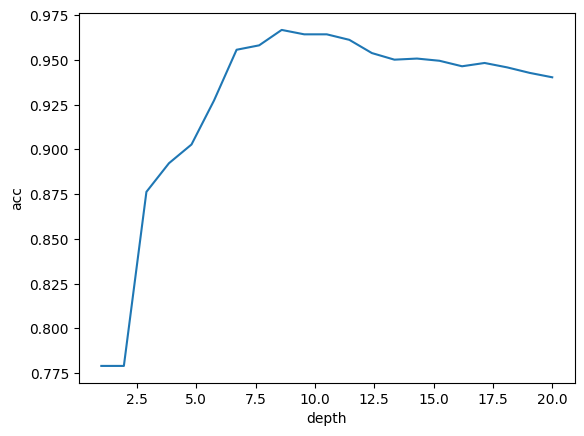

In [51]:
#### A3-P1 l) Repeat part (k), but now use the maximum tree depth as the hyperparameter. 
## create a plot acc vs depth, report suggest depth

depth = list(np.linspace(1, 20, 21))
acc = list()
for d in depth:
    d = int(d)
    model_gini = DecisionTreeClassifier(criterion="gini", max_depth=d)
    model_gini.fit(X_train, y_train)
    y_predict_gini = model_gini.predict(X_test)
    acc.append(sum((y_test - y_predict_gini) == 0)/len(y_predict_gini))

plt.plot(depth, acc)
plt.ylabel("acc")
plt.xlabel("depth")

# not too low depth.
# There is a sharp improvement with increase of depth, and then after which the improvement is minimal
# You will overfit if you increase the depth.


In [52]:
#### A3-P1 m) Create a 2D-heatmap showing model performance as a function of
# maximum tree depth and the minimum number of samples per leaf.
# Plot accuracy on the color scale.
# Generate separate heatmaps for train and test, ensuring that
# both colorbars use the same scale for meaningful visual comparison.
# Report your observations and discuss suitable choices for
# the tree depth andthe minimum number of samples per leaf.

leaf = list(np.linspace(1, 51, 26))
depth = list(np.linspace(1, 20, 21))
acc = np.zeros((26, 21))
acc_train = np.zeros((26, 21))
for i in range(len(leaf)):
    min_samples_leaf = int(leaf[i])
    for j in range(len(depth)):
        d = int(depth[j])
        model_gini = DecisionTreeClassifier(criterion="gini", max_depth=d, min_samples_leaf=min_samples_leaf)
        model_gini.fit(X_train, y_train)
        y_predict_gini = model_gini.predict(X_test)
        y_predict_gini_train = model_gini.predict(X_train)
        acc[i,j] = sum((y_test - y_predict_gini) == 0)/len(y_predict_gini)
        acc_train[i,j] = sum((y_train - y_predict_gini_train) == 0)/len(y_predict_gini_train)

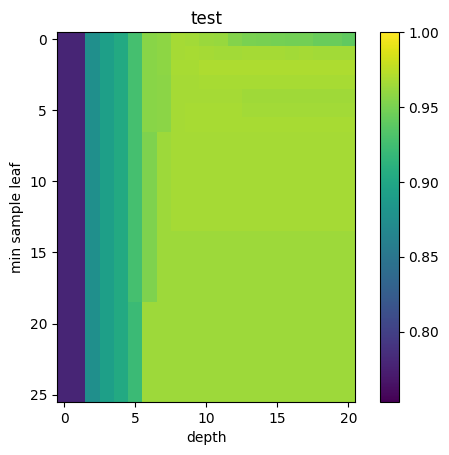

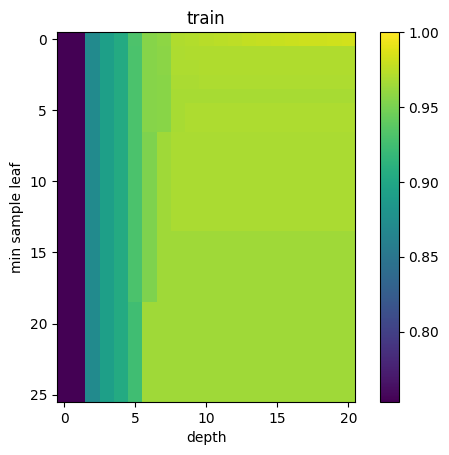

In [53]:
a = min([np.min(acc), np.min(acc_train)])
b = 1
plt.imshow(acc, vmin=a, vmax=b)
plt.ylabel("min sample leaf")
plt.xlabel("depth")
plt.title("test")
plt.colorbar();

plt.figure()
plt.imshow(acc_train, vmin=a, vmax=b)
plt.ylabel("min sample leaf")
plt.xlabel("depth")
plt.title("train")
plt.colorbar();

DecisionTreeClassifier(criterion=gini, max_depth=5)
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.91       880
           1       0.94      0.82      0.87       745

    accuracy                           0.89      1625
   macro avg       0.90      0.89      0.89      1625
weighted avg       0.90      0.89      0.89      1625

Confusion Matrix:
 [[841  39]
 [136 609]]


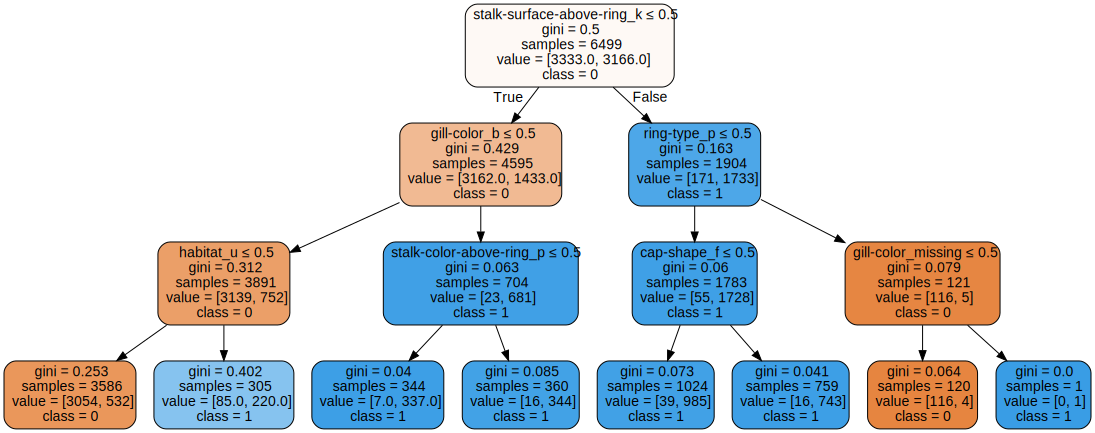

In [54]:
#### A3-P1 n) For a decision tree with limited depth,
# visualize the learned tree using \texttt{graphviz}.
# Interpret the tree and comment on the key features that are most useful.


from sklearn import tree
import graphviz

print("DecisionTreeClassifier(criterion=gini, max_depth=5)")

model_gini_depthlimited = DecisionTreeClassifier(criterion="gini", max_depth=3)
model_gini_depthlimited.fit(X_train, y_train)

# Measure the model's performance on the test set
y_predict_gini = model_gini_depthlimited.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_gini))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_gini))


feature_names = list(X.columns)

dot_data = tree.export_graphviz(model_gini_depthlimited, out_file=None, 
                      feature_names=feature_names,  
                      class_names=[str(c) for c in model_gini_depthlimited.classes_],  
                      filled=True, rounded=True,  
                      special_characters=True,
                            leaves_parallel=False)  
graph = graphviz.Source(dot_data)  
graph.render('tree',format = 'png');
graph

In [55]:
#### A3-P1 o) Repeat parts (i) through (m), but now use Entropy as the splitting criterion for the decision tree.
# Use sklearn for implementation. Feel free to explore a variety of
# hyperparameter settings and discuss their impact on model performance.

# Train the model using entropy
model_ent = DecisionTreeClassifier(criterion="entropy")
model_ent.fit(X_train, y_train)

# Measure the model's performance on the test set
y_predict_ent = model_ent.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_ent))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_ent))

# use min_samples_leaf to 2,20, report performance again

print("DecisionTreeClassifier(criterion=entropy, min_samples_leaf=2)")
model_ent_minsample = DecisionTreeClassifier(criterion="entropy", min_samples_leaf=2)
model_ent_minsample.fit(X_train, y_train)
y_predict_ent = model_ent_minsample.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_ent))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_ent))

print("DecisionTreeClassifier(criterion=entropy, min_samples_leaf=20)")
model_ent_minsample = DecisionTreeClassifier(criterion="entropy", min_samples_leaf=20)
model_ent_minsample.fit(X_train, y_train)
y_predict_ent = model_ent_minsample.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_ent))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_ent))

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.94       880
           1       0.94      0.93      0.93       745

    accuracy                           0.94      1625
   macro avg       0.94      0.94      0.94      1625
weighted avg       0.94      0.94      0.94      1625

Confusion Matrix:
 [[835  45]
 [ 55 690]]
DecisionTreeClassifier(criterion=entropy, min_samples_leaf=2)
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95       880
           1       0.96      0.92      0.94       745

    accuracy                           0.95      1625
   macro avg       0.95      0.94      0.95      1625
weighted avg       0.95      0.95      0.95      1625

Confusion Matrix:
 [[850  30]
 [ 57 688]]
DecisionTreeClassifier(criterion=entropy, min_samples_leaf=20)
Classification Report:
               precision    recall  f1-score   support

          

entropy


Text(0.5, 0, 'depth')

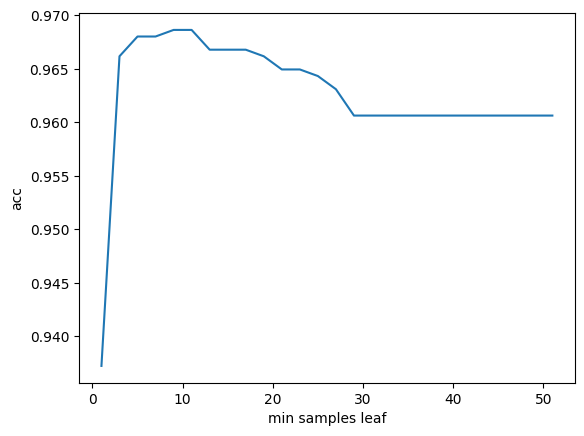

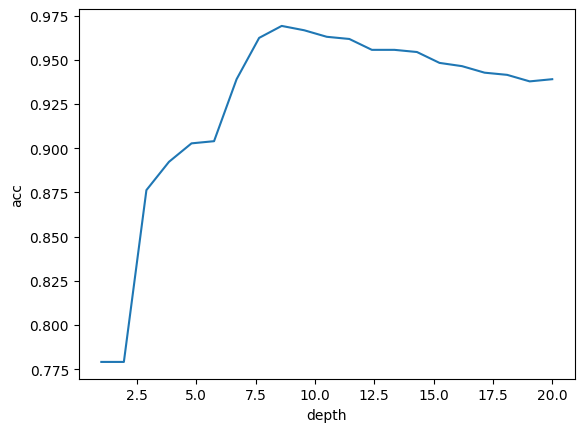

In [56]:
# create a plot acc vs min_samples_leaf
print("entropy")

leaf = list(np.linspace(1, 51, 26))
acc = list()
for min_samples_leaf in leaf:
    min_samples_leaf = int(min_samples_leaf)
    model_ent_minsample = DecisionTreeClassifier(criterion="entropy", min_samples_leaf=min_samples_leaf)
    model_ent_minsample.fit(X_train, y_train)
    y_predict_ent = model_ent_minsample.predict(X_test)
    acc.append(sum((y_test - y_predict_ent) == 0)/len(y_predict_ent))

plt.plot(leaf, acc)
plt.ylabel("acc")
plt.xlabel("min samples leaf")

depth = list(np.linspace(1, 20, 21))
acc = list()
for d in depth:
    d = int(d)
    model_ent = DecisionTreeClassifier(criterion="entropy", max_depth=d)
    model_ent.fit(X_train, y_train)
    y_predict_ent = model_ent.predict(X_test)
    acc.append(sum((y_test - y_predict_ent) == 0)/len(y_predict_ent))

plt.figure()
plt.plot(depth, acc)
plt.ylabel("acc")
plt.xlabel("depth")

# not too low depth.
# There is a sharp improvement with increase of depth, and then after which the improvement is minimal
# You will overfit if you increase the depth.



In [57]:
#### A3-P1 p) Repeat parts (i) through (o) using a Random Forest classifier.
# Report and discuss the impact of the number of trees (n_estimators) on model performance.
# Create plots showing performance as a function of both
# maximum tree depth and the number of trees, and comment on the observed trends.

from sklearn.ensemble import RandomForestClassifier

# Train the random forest classifier 
model_forest = RandomForestClassifier()
model_forest.fit(X_train, y_train)

# Measure the model's performance on the test set
y_predict_forest = model_forest.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_forest))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_forest))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.96       880
           1       0.95      0.96      0.96       745

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625

Confusion Matrix:
 [[843  37]
 [ 27 718]]


In [58]:
### train random forest and evaluate the model on test with varying the hyp (depth, n estimator)
## vary the depth and number of estimators and report the behaviour

print("n estimator 40, max_depth 2")
# Train the random forest classifier 
model_forest = RandomForestClassifier(n_estimators=40, random_state=0, max_depth=2)
model_forest.fit(X_train, y_train)

y_predict_forest_train = model_forest.predict(X_train)
print("Classification Report Train:\n", classification_report(y_train, y_predict_forest_train))

# Measure the model's performance on the test set
y_predict_forest = model_forest.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_forest))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_forest))

n estimator 40, max_depth 2
Classification Report Train:
               precision    recall  f1-score   support

           0       0.81      0.96      0.88      3333
           1       0.95      0.76      0.85      3166

    accuracy                           0.87      6499
   macro avg       0.88      0.86      0.87      6499
weighted avg       0.88      0.87      0.87      6499

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.97      0.89       880
           1       0.95      0.77      0.85       745

    accuracy                           0.88      1625
   macro avg       0.89      0.87      0.87      1625
weighted avg       0.89      0.88      0.87      1625

Confusion Matrix:
 [[852  28]
 [175 570]]


In [59]:
print("n estimator 100, max_depth 2")
# Train the random forest classifier 
model_forest = RandomForestClassifier(n_estimators=100, random_state=0, max_depth=2)
model_forest.fit(X_train, y_train)

y_predict_forest_train = model_forest.predict(X_train)
print("Classification Report Train:\n", classification_report(y_train, y_predict_forest_train))

# Measure the model's performance on the test set
y_predict_forest = model_forest.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_forest))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_forest))

n estimator 100, max_depth 2
Classification Report Train:
               precision    recall  f1-score   support

           0       0.81      0.98      0.89      3333
           1       0.97      0.76      0.85      3166

    accuracy                           0.87      6499
   macro avg       0.89      0.87      0.87      6499
weighted avg       0.89      0.87      0.87      6499

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.97      0.90       880
           1       0.96      0.77      0.85       745

    accuracy                           0.88      1625
   macro avg       0.90      0.87      0.88      1625
weighted avg       0.89      0.88      0.88      1625

Confusion Matrix:
 [[858  22]
 [174 571]]


In [60]:
### train random forest and evaluate the model on test with varying the hyp (depth, n estimator)
## vary the depth and number of estimators and report the behaviour

print("n estimator 3, max_depth 2")
# Train the random forest classifier 
model_forest = RandomForestClassifier(n_estimators=3, random_state=0, max_depth=2)
model_forest.fit(X_train, y_train)

y_predict_forest_train = model_forest.predict(X_train)
print("Classification Report Train:\n", classification_report(y_train, y_predict_forest_train))

# Measure the model's performance on the test set
y_predict_forest = model_forest.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_forest))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_forest))

n estimator 3, max_depth 2
Classification Report Train:
               precision    recall  f1-score   support

           0       0.81      0.98      0.88      3333
           1       0.97      0.76      0.85      3166

    accuracy                           0.87      6499
   macro avg       0.89      0.87      0.87      6499
weighted avg       0.89      0.87      0.87      6499

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.98      0.89       880
           1       0.96      0.75      0.84       745

    accuracy                           0.87      1625
   macro avg       0.89      0.86      0.87      1625
weighted avg       0.89      0.87      0.87      1625

Confusion Matrix:
 [[859  21]
 [187 558]]


In [61]:
print("n estimator 3, max_depth 20")
# Train the random forest classifier 
model_forest = RandomForestClassifier(n_estimators=3, random_state=0, max_depth=20)
model_forest.fit(X_train, y_train)

y_predict_forest_train = model_forest.predict(X_train)
print("Classification Report Train:\n", classification_report(y_train, y_predict_forest_train))

# Measure the model's performance on the test set
y_predict_forest = model_forest.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_forest))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_forest))

n estimator 3, max_depth 20
Classification Report Train:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      3333
           1       0.98      0.98      0.98      3166

    accuracy                           0.98      6499
   macro avg       0.98      0.98      0.98      6499
weighted avg       0.98      0.98      0.98      6499

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       880
           1       0.95      0.96      0.95       745

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625

Confusion Matrix:
 [[841  39]
 [ 32 713]]


In [62]:
### create a 2d heatmap on number of tree in the forest and the depth, report acc for both test and train.
# Discuss a suitable hyperparameter and why.
# set min_samples_leaf to 5.

num_trees = list(np.linspace(1, 51, 26))
depth = list(np.linspace(1, 20, 21))
acc_forest = np.zeros((26, 21))
acc_train_forest = np.zeros((26, 21))
for i in range(len(leaf)):
    nt = int(num_trees[i])
    for j in range(len(depth)):
        d = int(depth[j])
        model = RandomForestClassifier(n_estimators=nt, max_depth=d, min_samples_leaf=5)
        model.fit(X_train, y_train)
        y_predict = model.predict(X_test)
        y_predict_train = model.predict(X_train)
        acc_forest[i,j] = sum((y_test - y_predict) == 0)/len(y_predict)
        acc_train_forest[i,j] = sum((y_train - y_predict_train) == 0)/len(y_predict_train)

Forest


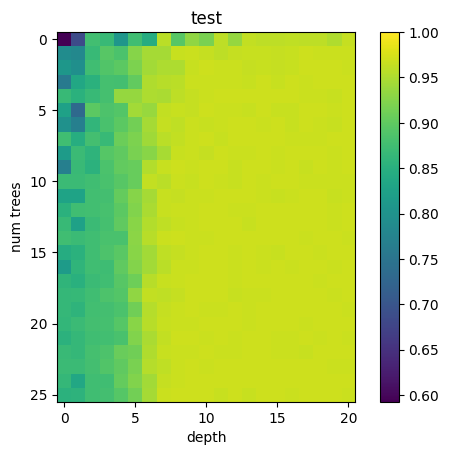

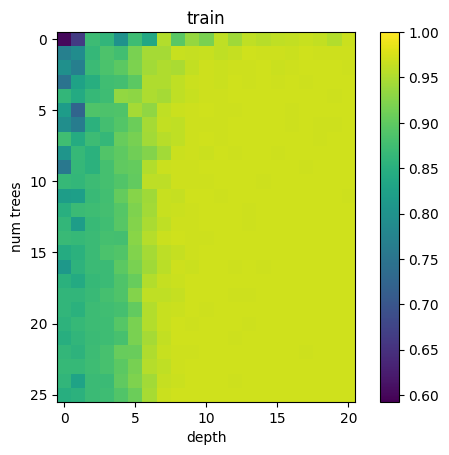

In [63]:
print("Forest")
a = min([np.min(acc_forest), np.min(acc_train_forest)])
b = 1
plt.imshow(acc_forest, vmin=a, vmax=b)
plt.ylabel("num trees")
plt.xlabel("depth")
plt.title("test")
plt.colorbar();

plt.figure()
plt.imshow(acc_train_forest, vmin=a, vmax=b)
plt.ylabel("num trees")
plt.xlabel("depth")
plt.title("train")
plt.colorbar();

In [64]:
#### A3-P1 q) Comment on the feature importance obtained from the Random Forest model
# and compare it with the feature importance from the Decision Tree.
# Discuss whether the most important features identified by these models align with
# the features you expected to be useful for classification based on your earlier visualizations.

# Train the random forest classifier 
model_forest = RandomForestClassifier(n_estimators=10, random_state=0, max_depth=10, min_samples_leaf=10)
model_forest.fit(X_train, y_train)

pd.Series(
    model_forest.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head()

stalk-surface-below-ring_k    0.152294
gill-color_b                  0.086959
stalk-surface-above-ring_k    0.086774
stalk-root_e                  0.046017
bruises_t                     0.043180
dtype: float64

In [68]:
#### A3-P1 r) Additionally, compute and visualize precision and recall for Random Forest
# as a function of the number of trees and the maximum tree depth. Comment on how these
# metrics change with these hyperparameters and discuss any trade-offs you observe.

from sklearn.metrics import precision_score, recall_score

num_trees = list(np.linspace(1, 51, 26))
depth = list(np.linspace(1, 20, 21))
acc_forest = np.zeros((26, 21))
acc_train_forest = np.zeros((26, 21))
precision_forest = np.zeros((26, 21))
recall_forest = np.zeros((26, 21))
precision_train_forest = np.zeros((26, 21))
recall_train_forest = np.zeros((26, 21))
for i in range(len(leaf)):
    nt = int(num_trees[i])
    for j in range(len(depth)):
        d = int(depth[j])
        model = RandomForestClassifier(n_estimators=nt, max_depth=d, min_samples_leaf=5)
        model.fit(X_train, y_train)
        y_predict = model.predict(X_test)
        y_predict_train = model.predict(X_train)
        acc_forest[i,j] = sum((y_test - y_predict) == 0)/len(y_predict)
        acc_train_forest[i,j] = sum((y_train - y_predict_train) == 0)/len(y_predict_train)
        precision_forest[i, j] = precision_score(y_test, y_predict)
        recall_forest[i, j] = recall_score(y_test, y_predict)
        precision_train_forest[i, j] = precision_score(y_train, y_predict_train)
        recall_train_forest[i, j] = recall_score(y_train, y_predict_train)

Forest Precision and Recall


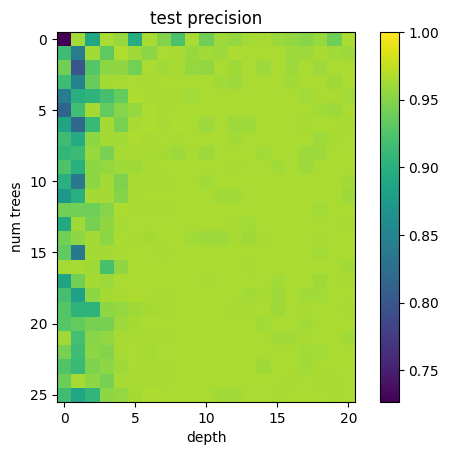

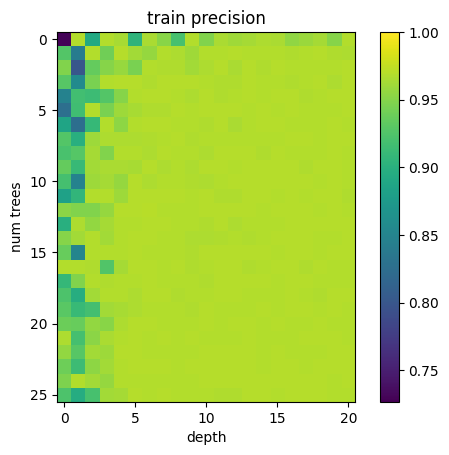

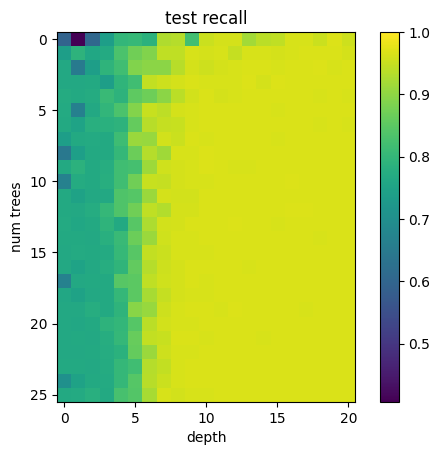

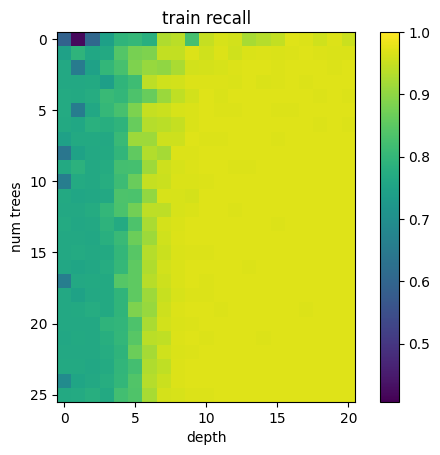

In [70]:
print("Forest Precision and Recall")
a = min([np.min(precision_forest), np.min(precision_train_forest)])
b = 1
plt.imshow(precision_forest, vmin=a, vmax=b)
plt.ylabel("num trees")
plt.xlabel("depth")
plt.title("test precision")
plt.colorbar();

plt.figure()
plt.imshow(precision_train_forest, vmin=a, vmax=b)
plt.ylabel("num trees")
plt.xlabel("depth")
plt.title("train precision")
plt.colorbar();

plt.figure()
a = min([np.min(recall_forest), np.min(recall_train_forest)])
b = 1
plt.imshow(recall_forest, vmin=a, vmax=b)
plt.ylabel("num trees")
plt.xlabel("depth")
plt.title("test recall")
plt.colorbar();

plt.figure()
plt.imshow(recall_train_forest, vmin=a, vmax=b)
plt.ylabel("num trees")
plt.xlabel("depth")
plt.title("train recall")
plt.colorbar();

In [71]:
#### A3-P1 s) Use sklearn to train a SVM on your data and report its performance.
# Visualize the learned coefficients of the SVM model and identify which features
# the SVM relies on most for classification. Compare these features with the
# important features identified by the Decision Tree model and discuss any similarities or differences.

from sklearn.svm import SVC

model_svm_linear = SVC(kernel='linear')
model_svm_linear.fit(X_train, y_train)

y_predict_svm_linear_train = model_svm_linear.predict(X_train)
print("Classification Report Train:\n", classification_report(y_train, y_predict_svm_linear_train))
print("Confusion Matrix Train:\n", confusion_matrix(y_train, y_predict_svm_linear_train))

y_predict_svm_linear = model_svm_linear.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_svm_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_svm_linear))

Classification Report Train:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97      3333
           1       0.97      0.97      0.97      3166

    accuracy                           0.97      6499
   macro avg       0.97      0.97      0.97      6499
weighted avg       0.97      0.97      0.97      6499

Confusion Matrix Train:
 [[3235   98]
 [  88 3078]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       880
           1       0.97      0.97      0.97       745

    accuracy                           0.97      1625
   macro avg       0.97      0.97      0.97      1625
weighted avg       0.97      0.97      0.97      1625

Confusion Matrix:
 [[854  26]
 [ 25 720]]


1 : important value feature has index of 45 the feature is stalk-root_r
2 : important value feature has index of 26 the feature is gill-color_b
3 : important value feature has index of 31 the feature is gill-color_missing
4 : important value feature has index of 42 the feature is stalk-root_b
5 : important value feature has index of 41 the feature is stalk-root_?
6 : important value feature has index of 82 the feature is population_a
7 : important value feature has index of 76 the feature is ring-number_t
8 : important value feature has index of 43 the feature is stalk-root_c
9 : important value feature has index of 78 the feature is ring-type_f
10 : important value feature has index of 40 the feature is stalk-shape_t


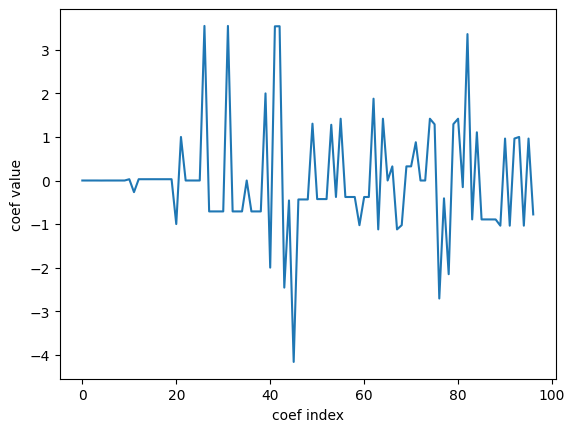

In [72]:
#### weights

plt.plot(model_svm_linear.coef_[0,:])
plt.xlabel("coef index")
plt.ylabel("coef value");

sorted_indices = np.argsort(np.abs(model_svm_linear.coef_))[0][::-1]
# print(sorted_indices)

ctr = 0
for kk in sorted_indices[:10]:
    ctr += 1
    print(ctr, ": important value feature has index of", kk, "the feature is", feature_names[kk])


In [74]:
#### A3-P1 t) Use SGDClassifier from sklearn.linear_model to train a linear classifier
# using the separation criterion (i.e., hinge loss).
# Report the performance and discuss the results.

from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline

model_hinge = make_pipeline(SGDClassifier(loss='hinge'))

model_hinge.fit(X_train, y_train)

# Measure the model's performance on the test set
y_predict_hinge = model_hinge.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_hinge))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_hinge))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       880
           1       0.97      0.97      0.97       745

    accuracy                           0.97      1625
   macro avg       0.97      0.97      0.97      1625
weighted avg       0.97      0.97      0.97      1625

Confusion Matrix:
 [[854  26]
 [ 25 720]]


In [75]:
#### A3-P1 u) Report the impact of data normalization or standardization (hint: use StandardScaler).

model_hinge_scaled = make_pipeline(StandardScaler(with_mean=False), SGDClassifier(loss='hinge'))

model_hinge_scaled.fit(X_train, y_train)

# Measure the model's performance on the test set
y_predict_hinge_scaled = model_hinge_scaled.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_hinge_scaled))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_hinge_scaled))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       880
           1       0.97      0.97      0.97       745

    accuracy                           0.97      1625
   macro avg       0.97      0.97      0.97      1625
weighted avg       0.97      0.97      0.97      1625

Confusion Matrix:
 [[854  26]
 [ 24 721]]


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       880
           1       0.97      0.97      0.97       745

    accuracy                           0.97      1625
   macro avg       0.97      0.97      0.97      1625
weighted avg       0.97      0.97      0.97      1625

Confusion Matrix:
 [[854  26]
 [ 24 721]]
(1, 97)
SGDClassifier, model_hinge_scaled_balanced
1 : important value feature has index of 26 the feature is gill-color_b
2 : important value feature has index of 43 the feature is stalk-root_c
3 : important value feature has index of 45 the feature is stalk-root_r
4 : important value feature has index of 39 the feature is stalk-shape_e
5 : important value feature has index of 42 the feature is stalk-root_b
6 : important value feature has index of 40 the feature is stalk-shape_t
7 : important value feature has index of 82 the feature is population_a
8 : important value feature has index of 1 the fea

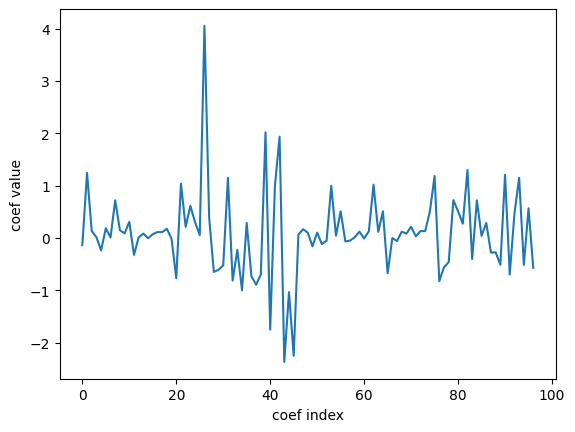

In [76]:
#### A3-P1 v) Report the impact of class imbalance on model performance and discuss methods to address this issue without removing data.
# Describe your observations and explain how these techniques affect the results.

model_hinge_scaled_balanced = make_pipeline(StandardScaler(with_mean=False), SGDClassifier(loss='hinge', class_weight="balanced"))

model_hinge_scaled_balanced.fit(X_train, y_train)
y_predict_hinge_scaled_balanced = model_hinge_scaled_balanced.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_predict_hinge_scaled_balanced))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_hinge_scaled_balanced))

w_hinge_scaled_balanced = model_hinge_scaled_balanced.named_steps["sgdclassifier"].coef_


print(w_hinge_scaled_balanced.shape)
print("SGDClassifier, model_hinge_scaled_balanced")
plt.plot(w_hinge_scaled_balanced[0,:])
plt.xlabel("coef index")
plt.ylabel("coef value");

sorted_indices = np.argsort(np.abs(w_hinge_scaled_balanced))[0][::-1]

ctr = 0
for kk in sorted_indices[:10]:
    ctr += 1
    print(ctr, ": important value feature has index of", kk, "the feature is", feature_names[kk])


In [ ]:
#### A3-P1 w) Based on the learned coefficients, visualize their values and comment
# on their importance for classification. Discuss whether these important features
# differ from those identified by the Decision Tree model, and explain whether
# they align with your initial expectations about which features are most useful
# for predicting the target class.

# Check the printed features above and to those of decision tree.

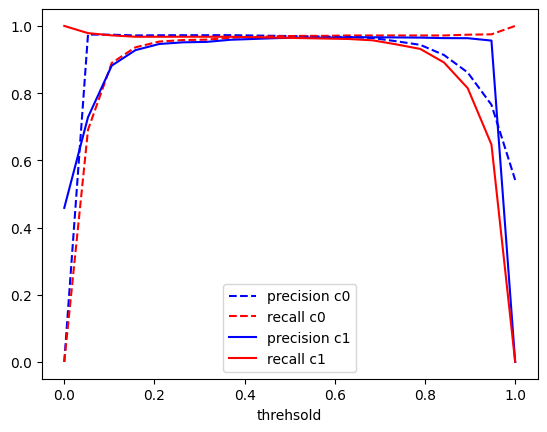

In [ ]:
#### A3-P1 x) Logistic Regression

import numpy as np
from sklearn.linear_model import LogisticRegression

# Train your model
model = LogisticRegression()

model.fit(X_train, y_train)

# Get probabilities
probabilities = model.predict_proba(X_test)

# Custom threshold function
def custom_predict(probabilities, threshold):
    return (probabilities[:, 1] >= threshold).astype(int)


precision_c0 = list()
recall_c0 = list()
precision_c1 = list()
recall_c1 = list()
th_list = np.linspace(0.00001,0.99999,20)
for th in th_list:
    y_predict_lr2 = custom_predict(probabilities, threshold=th)

    report = classification_report(y_test, y_predict_lr2, output_dict=True)
    class0_p = report["0"]["precision"]
    class0_r = report["0"]["recall"]
    class1_p = report["1"]["precision"]
    class1_r = report["1"]["recall"]

    precision_c0.append(class0_p)
    recall_c0.append(class0_r)
    precision_c1.append(class1_p)
    recall_c1.append(class1_r)

plt.plot(th_list, precision_c0, "--", color="blue", label="precision c0")
plt.plot(th_list, recall_c0, "--", color="red", label="recall c0")
plt.plot(th_list, precision_c1, color="blue", label="precision c1")
plt.plot(th_list, recall_c1, color="red", label="recall c1")
plt.xlabel("threhsold")
plt.legend();

#### A3-P1 y) the impact of threshold is clear on the feature, and
# that the classifier is not sensitive to the threhsold
# #(there is a large values of threshold between 0.3 and 0.7 that gives similar results.

In [656]:
### Perform comparison of the obtained models,
# i.e., perform 10-fold cross validation with cross_val_score(), and T-test.

from scipy.stats import ttest_ind

print("Comparing each model using 10-fold cross validation\n")

score_gini = cross_val_score(model_gini, X, y, cv=10)
print("Gini Model: \n", score_gini)
print("Average: ", sum(score_gini)/10, "\n")

score_ent = cross_val_score(model_ent, X, y, cv=10)
print("Entropy Model: \n", score_ent)
print("Average: ", sum(score_ent)/10, "\n")

score_forest = cross_val_score(model_forest, X, y, cv=10)
print("Random Forest Model: \n", score_forest)
print("Average: ", sum(score_forest)/10, "\n")

score_hinge = cross_val_score(model_hinge, X, y, cv=10)
print("SGD Hinge: \n", score_hinge)
print("Average: ", sum(score_hinge)/10, "\n")

Comparing each model using 10-fold cross validation

Gini Model: 
 [0.59778598 0.87207872 0.98400984 0.9901599  0.93596059 0.93472906
 0.99261084 0.96182266 0.60714286 0.841133  ]
Average:  0.8717433455122728 

Entropy Model: 
 [0.59655597 0.91512915 0.96678967 0.96432964 0.95935961 0.93842365
 0.96059113 0.89901478 0.82512315 0.93226601]
Average:  0.8957582753167435 

Random Forest Model: 
 [0.59655597 0.9803198  0.99507995 0.99384994 0.97906404 0.94704433
 0.99137931 0.96305419 0.81773399 0.91995074]
Average:  0.9184032259041801 

SGD Hinge: 
 [0.60393604 0.9200492  0.99630996 0.99753998 0.99384236 0.99630542
 0.99261084 0.96305419 0.84605911 0.96182266]
Average:  0.9271529759632571 



In [657]:
score_hinge_scaled = cross_val_score(model_hinge_scaled, X, y, cv=10)
print("SGD Hinge Scaled: \n", score_hinge_scaled)
print("Average: ", sum(score_hinge_scaled)/10, "\n")

score_hinge_scaled_balanced = cross_val_score(model_hinge_scaled_balanced, X, y, cv=10)
print("SGD Hinge Scaled Balanced: \n", score_hinge_scaled_balanced)
print("Average: ", sum(score_hinge_scaled_balanced)/10, "\n")

SGD Hinge Scaled: 
 [0.61131611 0.96063961 0.99384994 0.99753998 0.99507389 0.96428571
 0.99261084 0.96305419 0.83128079 0.96182266]
Average:  0.9271473712274068 

SGD Hinge Scaled Balanced: 
 [0.61131611 0.95817958 0.99384994 0.98892989 0.99384236 0.99261084
 0.99261084 0.96305419 0.79679803 0.96182266]
Average:  0.9253014439011384 



In [658]:
print("Comparing each model using T-tests and the scores from the cross validation\n")

print("p-value of T-test between Gini model and Entropy model: ", ttest_ind(score_gini, score_ent).pvalue)
print("p-value of T-test between Gini model and Random Forest model: ", ttest_ind(score_gini, score_forest).pvalue)
print("p-value of T-test between Entropy model and Random Forest model: ", ttest_ind(score_ent, score_forest).pvalue)
print("p-value of T-test between Entropy model and SGD Hinge: ", ttest_ind(score_ent, score_hinge).pvalue)

Comparing each model using T-tests and the scores from the cross validation

p-value of T-test between Gini model and Entropy model:  0.6916484066102538
p-value of T-test between Gini model and Random Forest model:  0.46042904059810696
p-value of T-test between Entropy model and Random Forest model:  0.6767532012732659
p-value of T-test between Entropy model and SGD Hinge:  0.5610394769719124


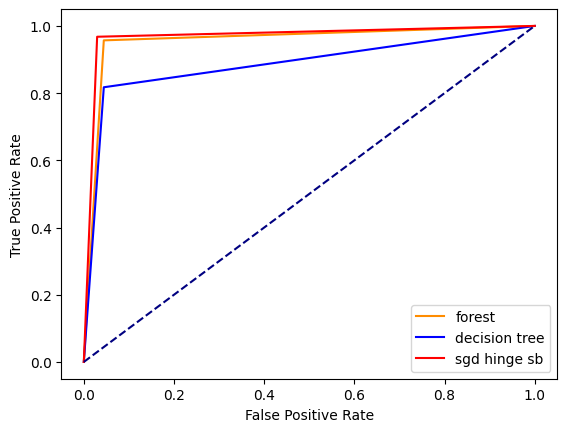

In [ ]:
# #### A3-P1 z) ROC 

from sklearn.metrics import roc_curve, auc

# Compute ROC curve and ROC area
fpr, tpr, _ = roc_curve(y_test, y_predict_forest, pos_label=1)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', label="forest")

fpr, tpr, _ = roc_curve(y_test, y_predict_gini, pos_label=1)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', label="decision tree")

fpr, tpr, _ = roc_curve(y_test, y_predict_hinge_scaled_balanced, pos_label=1)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='red', label="sgd hinge sb")


plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show();

# sgd hinge and forest are good models (better than decision tree).

In [79]:
# #### A3-P1 end) Repeat your analysis after removing a subset of the important features you identified, and report the resulting drop in performance.

# This is an open-ended question, you can remove the feature from the beginning of the notebook and re-run.